In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import collections
import functools
import os
import pathlib
import typing

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import common_data

In [3]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200
%config InlineBackend.figure_format = "retina"

In [4]:
def sanitize_name(name):
    return name.replace(' ', '_').replace('*', '').replace(';', '_and').replace('/', '_')

# Save new DEG tasks

Here are some new tasks

* Gram+ vs Gram–
* Pseudomonas vs Other Gram–
* Age: <65
* Sex
* Immunocompromised
* Days on vent Q1 vs Q4
* ICU steroid dose < median

In [ ]:
BASE = common_data.DATA / '05_pseudobulk/50a_other_degs'

In [6]:
os.makedirs(BASE, exist_ok=True)

In [7]:
categorical = common_data.get_sc_categorical_covariates()
numerical = common_data.get_sc_numerical_covariates()
sc_labels = pd.read_csv(common_data.SC_LABELS, index_col=0)

Text(15, 0, '$median=600.0$')

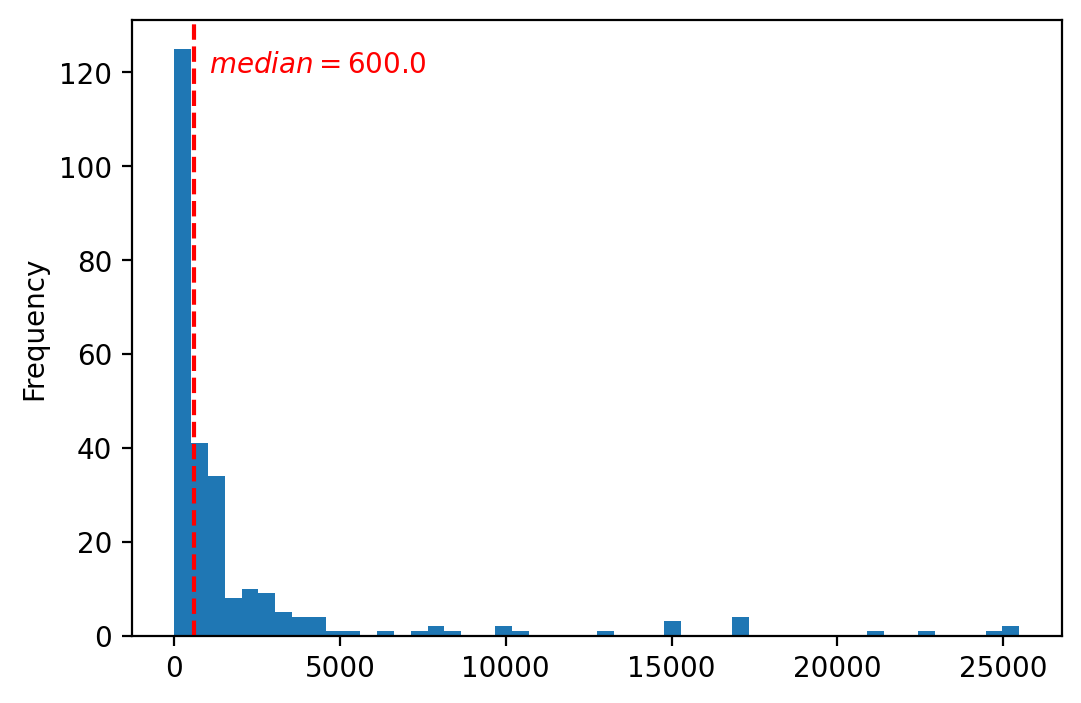

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
numerical.cumulative_icu_steroid_dose_until_today.plot.hist(bins=50, ax=ax)
ax.axvline(numerical.cumulative_icu_steroid_dose_until_today.median(), ls='--', c='r')
ax.annotate(
    f'$median={numerical.cumulative_icu_steroid_dose_until_today.median()}$',
    (numerical.cumulative_icu_steroid_dose_until_today.median(), 120),
    xytext=(15, 0),
    textcoords='offset pixels',
    c='r'
)

In [10]:
numerical.days_on_ventilator.quantile(0.25)

2.0

In [11]:
numerical.days_on_ventilator.quantile(0.75)

16.0

In [12]:
numerical['cohort'] = sc_labels.set_index('bal_barcode').cohort

In [13]:
categorical['cohort'] = sc_labels.set_index('bal_barcode').cohort

In [14]:
numerical['age_over_64'] = numerical.Age.gt(64) & numerical.cohort.eq('SCRIPT')
numerical['steroid_over_median'] = numerical.cumulative_icu_steroid_dose_until_today.gt(
    numerical.cumulative_icu_steroid_dose_until_today.median()
) & numerical.cohort.eq('SCRIPT')
numerical['vent_q1'] = (
    numerical.days_on_ventilator.lt(numerical.days_on_ventilator.quantile(0.25))
    & numerical.cohort.eq('SCRIPT')
)
numerical['vent_q4'] = (
    numerical.days_on_ventilator.gt(numerical.days_on_ventilator.quantile(0.75))
    & numerical.cohort.eq('SCRIPT')
)

In [15]:
numerical.age_over_64.value_counts(dropna=False)

False    217
True      84
Name: age_over_64, dtype: int64

In [16]:
numerical.steroid_over_median.value_counts(dropna=False)

False    171
True     130
Name: steroid_over_median, dtype: int64

In [17]:
numerical.vent_q1.value_counts(dropna=False)

False    248
True      53
Name: vent_q1, dtype: int64

In [18]:
numerical.vent_q4.value_counts(dropna=False)

False    239
True      62
Name: vent_q4, dtype: int64

In [19]:
tasks = [
    'gram+_vs_gram-',
    'pseudomonas_vs_gram-',
    'age',
    'sex',
    'immunocompromised',
    'days_on_vent',
    'steroid_dose'
]

In [20]:
def get_positive_label(task, cat, num):
    if task == 'gram+_vs_gram-':
        return cat.Pathogen_groups.isin(['Gram-*', 'Pseudomonas aeruginosa'])
    if task == 'pseudomonas_vs_gram-':
        return cat.Pathogen_groups.eq('Gram-*')
    if task == 'age':
        return num.age_over_64 & num.cohort.eq('SCRIPT')
    if task == 'sex':
        return cat.Sex.eq('Female') & num.cohort.eq('SCRIPT')
    if task == 'immunocompromised':
        return cat.Immunocompromised_flag.eq('1')
    if task == 'days_on_vent':
        return num.vent_q4
    if task == 'steroid_dose':
        return num.steroid_over_median & num.cohort.eq('SCRIPT')
    raise ValueError(f'Unknown task {task}')

In [21]:
def get_negative_label(task, cat, num):
    if task == 'gram+_vs_gram-':
        return cat.Pathogen_groups.eq('Gram+')
    if task == 'pseudomonas_vs_gram-':
        return cat.Pathogen_groups.eq('Pseudomonas aeruginosa')
    if task == 'age':
        return ~num.age_over_64 & num.cohort.eq('SCRIPT')
    if task == 'sex':
        return cat.Sex.eq('Male') & num.cohort.eq('SCRIPT')
    if task == 'immunocompromised':
        return cat.Immunocompromised_flag.eq('0')
    if task == 'days_on_vent':
        return num.vent_q1
    if task == 'steroid_dose':
        return ~num.steroid_over_median & num.cohort.eq('SCRIPT')
    raise ValueError(f'Unknown task {task}')

In [22]:
for task in tasks:
    pos_idx = get_positive_label(task, categorical, numerical)
    neg_idx = get_negative_label(task, categorical, numerical)
    pos_samples = categorical.index[pos_idx]
    neg_samples = categorical.index[neg_idx]
    meta = pd.concat([
        pd.DataFrame({
            'bal_barcode': pos_samples,
            'group': 1
        }),
        pd.DataFrame({
            'bal_barcode': neg_samples,
            'group': 0
        })
    ])
    os.makedirs(BASE / task, exist_ok=True)
    meta.to_csv(BASE / task / '_group_labels.csv')